In [1]:
import xarray as xr
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmocean as cmo

import sys

sys.path.append('../src')
import utils as ut
import warnings
warnings.filterwarnings("ignore")

In [2]:
#Get time-independent variables
ds = xr.open_dataset('../data/ecefiles/areas.nc')
area = ds['O1t0.srf'].values;
ds.close()

fnames = sorted(glob.glob(f'../rawdata/ecefiles/n011/n011*.nc'))

ds = xr.open_dataset(fnames[0])
lat = ds['nav_lat'].values
lon = ds['nav_lon'].values
levmid = ds['olevel'].values
lev = ds['olevel_bounds'].values
time_bnds = ds['time_centered_bounds']
thick = ds['e3t'].values #Quasi-time-independent, treated as fixed


ds.close()
secs = (time_bnds[:12,1]-time_bnds[:12,0]).values / np.timedelta64(1, 's')

months = np.arange(0,12)

In [48]:
def get_section(run,var,t0,t1,verbose=True):

    assert var in ['thetao','so']
    
    jmax = 45
    
    Vall = np.zeros((len(ut.basin),len(levmid),jmax))  
    
    lons = np.repeat(lon[np.newaxis,:jmax,:],len(levmid),axis=0)
    lats = np.repeat(lat[np.newaxis,:jmax,:],len(levmid),axis=0)
    mask = np.repeat(np.zeros(lons.shape)[np.newaxis,:,:,:],len(ut.basin),axis=0)
    
    zz = np.zeros(len(ut.basin))
    
    for b,bas in enumerate(ut.basin):
        mm = np.nan*np.zeros(lons.shape)
        if bas=='East Ant.':
            #EAIS
            mm[((lons<173) & (lons>-10)) & (lats<-65) & (lats>-76)] = 1
            zz[b] = 369
        if bas=='Ross':
            #ROSS
            mm[((lons>150) | (lons<-150)) & (lats<-76)] = 1
            zz[b] = 312        
        if bas=='Amundsen':
            #AMUN
            mm[(lons>-150) & (lons<-80) & (lats<-70)] = 1
            zz[b] = 305
        if bas=='Weddell':
            #WEDD
            mm[(lons>-65) & (lons<-10) & (lats<-72)] = 1
            zz[b] = 420
        if bas=='Peninsula':
            #APEN
            mm[(lons>-66) & (lons<-56) & (lats>-70) & (lats<-65)] = 1
            mm[(lons>-80) & (lons<-65) & (lats>-75) & (lats<-70)] = 1
            zz[b] = 420
        mask[b,:,:,:] = mm
    
    if run=='n011':
        tt0 = t0+100
        tt1 = t1+100
    else:
        tt0 = t0
        tt1 = t1

    if run=='piControl':
        fnames = sorted(glob.glob(f'../rawdata/ecefiles/cmip6/{var}_Omon_EC-Earth3_{run}*.nc'))
        nyears = len(fnames)
    else:    
        fnames = sorted(glob.glob(f'../rawdata/ecefiles/{run}/{run}*grid_T.nc'))
        nyears = 0
        for fname in fnames:
            ds = xr.open_dataset(fname)
            nyears += int(np.floor(len(ds.time_counter)/12))
            ds.close()
    assert nyears >= tt1,f'Time series too short, reduce t1'

    V = np.zeros((nyears,len(ut.basin),len(levmid),jmax))
    
    if verbose: print('Getting',var,'from',run)
    c = -1
    for f,fname in enumerate(fnames):
        if c >= tt1:
            #print(year0+y,c,run,'finished')
            break
        ds = xr.open_dataset(fname)
        
        if run=='piControl':
            time = ds['time'].values
            year0 = int(fname[-16:-12])
        else:
            time = ds['time_centered'].values 
            year0 = int(fname[-27:-23])

        ny = int(len(time)/12)
        if c+ny<tt0:
            c += ny
            #print(year0,c,'skipping file')
            continue

        if run=='piControl':
            ds = ds.sel(j=slice(0,jmax))
            lat0 = ds['latitude'].mean(dim='i').values
        else:
            ds = ds.sel(y=slice(0,jmax))
            lat0 = ds['nav_lat'].mean(dim='x').values
            
        varb = ds[var]
        ds.close()

        for y in np.arange(0,ny):
            c += 1
            if c<tt0:
                #print(year0+y,c,'skipping year')
                continue            
            if c >= tt1:
                #print(year0+y,c,'got all years')
                break
            vb = np.zeros((len(levmid),jmax,lon.shape[1]))
            for m,mm in enumerate(months):
                vbb = varb[m+12*y,:,:,:]
                vb += vbb*secs[m]
            for b,bas in enumerate(ut.basin):
                V[c,b,:,:] = np.nanmean(vb/sum(secs)*mask[b,:,:,:],axis=-1)
            if verbose: print('Got year',year0+y)

    Vall[:,:,:] = V[tt0:tt1,:,:,:].mean(axis=0)
    if verbose: print('-------------')
    return Vall,lat0,zz

In [38]:
def plot_TS_anom(plotvars,cmaps,vmin,vmax,ylabels,lat0,latmin,latmax,zz,title=None,savename=None):

    plt.style.use('../src/style_paper')
    mpl.rcParams['figure.subplot.top'] = .9
    mpl.rcParams['figure.subplot.wspace'] = .25
    
    fig,ax = plt.subplots(len(plotvars),len(ut.basin),sharey=True)

    for b,bas in enumerate(ut.basin):
        
        for v,vv in enumerate(plotvars):
            cmapp = plt.get_cmap(cmaps[v]).copy()
            cmapp.set_bad('.8')

            im = ax[v,b].pcolormesh(lat0,-levmid,vv[b,:,:],shading='nearest',cmap=cmapp,vmin=vmin[v],vmax=vmax[v])
            if b==4:
                plt.colorbar(im,ax=ax[v,b],extend='both')
            ax[v,b].fill_between(lat0,lat0*0-zz[b]-50,lat0*0-zz[b]+50,color=ut.bcol[bas],alpha=.2)
            if b==0:
                ax[v,b].set_ylabel(ylabels[v])

            ax[v,b].set_xlim([latmin[b],latmax[b]])
            if v<2:
                ax[v,b].set_xticklabels([])                
    
        ax[0,b].set_title(bas,c=ut.bcol[bas])
        
    ax[0,0].set_ylim([-750,0])

    ax[-1,2].set_xlabel('Latitude [deg S]')
    fig.suptitle(title)
    #fig.supylabel('Depth [m]')

    if savename is not None:
        plt.savefig(savename,dpi=450)
        print(f'Saved {savename}')
    plt.show()

In [44]:
T0c,lat0,zz = get_section('piControl','thetao',0,500)
T1c,lat0,zz = get_section('n011','thetao',0,150)

Getting thetao from piControl
Got year 2259
Got year 2260
Got year 2261
Got year 2262
Got year 2263
Got year 2264
Got year 2265
Got year 2266
Got year 2267
Got year 2268
Got year 2269
Got year 2270
Got year 2271
Got year 2272
Got year 2273
Got year 2274
Got year 2275
Got year 2276
Got year 2277
Got year 2278
Got year 2279
Got year 2280
Got year 2281
Got year 2282
Got year 2283
Got year 2284
Got year 2285
Got year 2286
Got year 2287
Got year 2288
Got year 2289
Got year 2290
Got year 2291
Got year 2292
Got year 2293
Got year 2294
Got year 2295
Got year 2296
Got year 2297
Got year 2298
Got year 2299
Got year 2300
Got year 2301
Got year 2302
Got year 2303
Got year 2304
Got year 2305
Got year 2306
Got year 2307
Got year 2308
Got year 2309
Got year 2310
Got year 2311
Got year 2312
Got year 2313
Got year 2314
Got year 2315
Got year 2316
Got year 2317
Got year 2318
Got year 2319
Got year 2320
Got year 2321
Got year 2322
Got year 2323
Got year 2324
Got year 2325
Got year 2326
Got year 2327
Got 

Saved ../draftfigs/sections.png


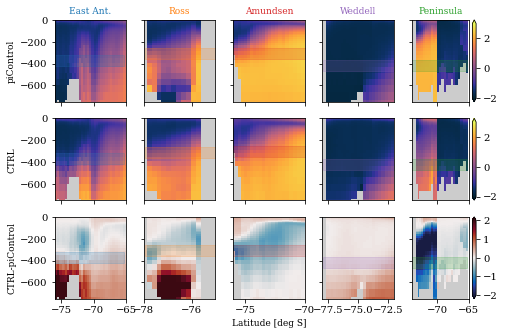

In [45]:
plotvars = [T0c,T1c,T1c-T0c]
cmaps = np.array(['cmo.thermal','cmo.thermal','cmo.balance'])
vmin = np.array([-2,-2,-2])
vmax = np.array([3,3,2])
ylabels = ['piControl','CTRL','CTRL-piControl']
latmin = [-76,-78,-76,-78,-74]
latmax = [-65,-75,-70,-72,-65]
    
plot_TS_anom(plotvars,cmaps,vmin,vmax,ylabels,lat0,latmin,latmax,zz,savename=f'../draftfigs/sections.png')


In [52]:
T0c,lat0,zz = get_section('n011','thetao',0,150)
T1c,lat0,zz = get_section('hal2','thetao',75,150)

Getting thetao from n011
Got year 1950
Got year 1951
Got year 1952
Got year 1953
Got year 1954
Got year 1955
Got year 1956
Got year 1957
Got year 1958
Got year 1959
Got year 1960
Got year 1961
Got year 1962
Got year 1963
Got year 1964
Got year 1965
Got year 1966
Got year 1967
Got year 1968
Got year 1969
Got year 1970
Got year 1971
Got year 1972
Got year 1973
Got year 1974
Got year 1975
Got year 1976
Got year 1977
Got year 1978
Got year 1979
Got year 1980
Got year 1981
Got year 1982
Got year 1983
Got year 1984
Got year 1985
Got year 1986
Got year 1987
Got year 1988
Got year 1989
Got year 1990
Got year 1991
Got year 1992
Got year 1993
Got year 1994
Got year 1995
Got year 1996
Got year 1997
Got year 1998
Got year 1999
Got year 2000
Got year 2001
Got year 2002
Got year 2003
Got year 2004
Got year 2005
Got year 2006
Got year 2007
Got year 2008
Got year 2009
Got year 2010
Got year 2011
Got year 2012
Got year 2013
Got year 2014
Got year 2015
Got year 2016
Got year 2017
Got year 2018
Got year 

Saved ../draftfigs/sections_all1.png


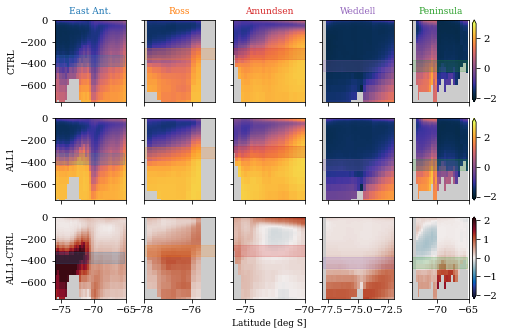

In [53]:
plotvars = [T0c,T1c,T1c-T0c]
cmaps = np.array(['cmo.thermal','cmo.thermal','cmo.balance'])
vmin = np.array([-2,-2,-2])
vmax = np.array([3,3,2])
ylabels = ['CTRL','ALL1','ALL1-CTRL']
latmin = [-76,-78,-76,-78,-74]
latmax = [-65,-75,-70,-72,-65]
    
plot_TS_anom(plotvars,cmaps,vmin,vmax,ylabels,lat0,latmin,latmax,zz,savename=f'../draftfigs/sections_all1.png')